
FIRST 5 ROWS
  country country_long                                              name  \
0     AFG  Afghanistan      Kajaki Hydroelectric Power Plant Afghanistan   
1     AFG  Afghanistan                                      Kandahar DOG   
2     AFG  Afghanistan                                      Kandahar JOL   
3     AFG  Afghanistan     Mahipar Hydroelectric Power Plant Afghanistan   
4     AFG  Afghanistan  Naghlu Dam Hydroelectric Power Plant Afghanistan   

      gppd_idnr  capacity_mw  latitude  longitude primary_fuel other_fuel1  \
0  GEODB0040538         33.0    32.322    65.1190        Hydro         NaN   
1    WKS0070144         10.0    31.670    65.7950        Solar         NaN   
2    WKS0071196         10.0    31.623    65.7920        Solar         NaN   
3  GEODB0040541         66.0    34.556    69.4787        Hydro         NaN   
4  GEODB0040534        100.0    34.641    69.7170        Hydro         NaN   

  other_fuel2  ... estimated_generation_gwh_2013  \
0       

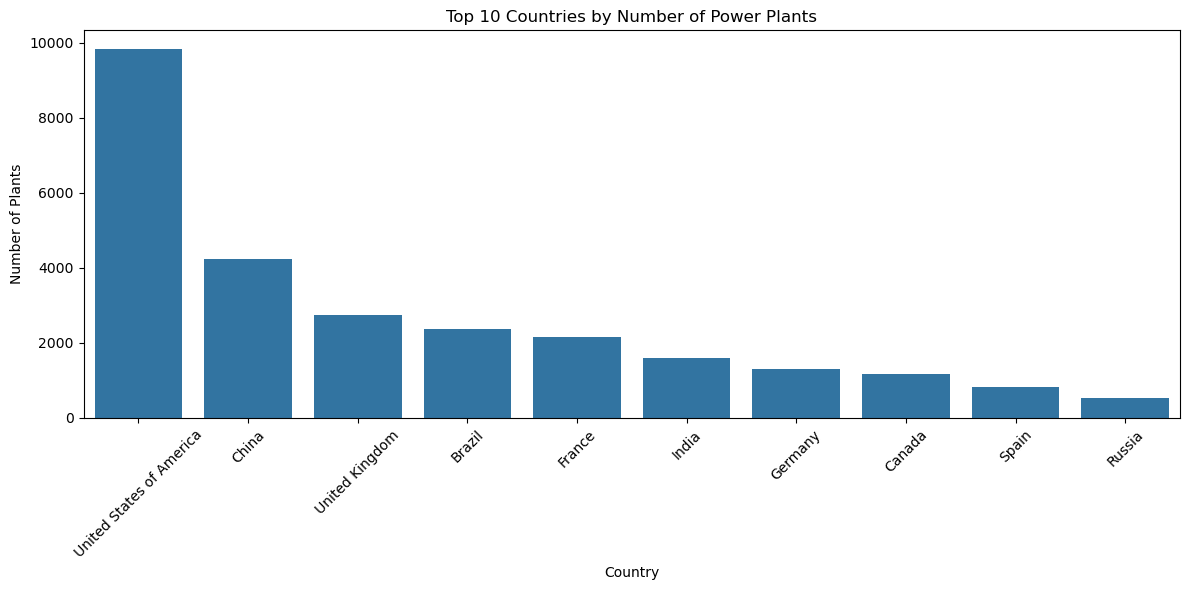


FUEL TYPE DISTRIBUTION
primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneration         41
Petcoke              12
Wave and Tidal       10
Name: count, dtype: int64


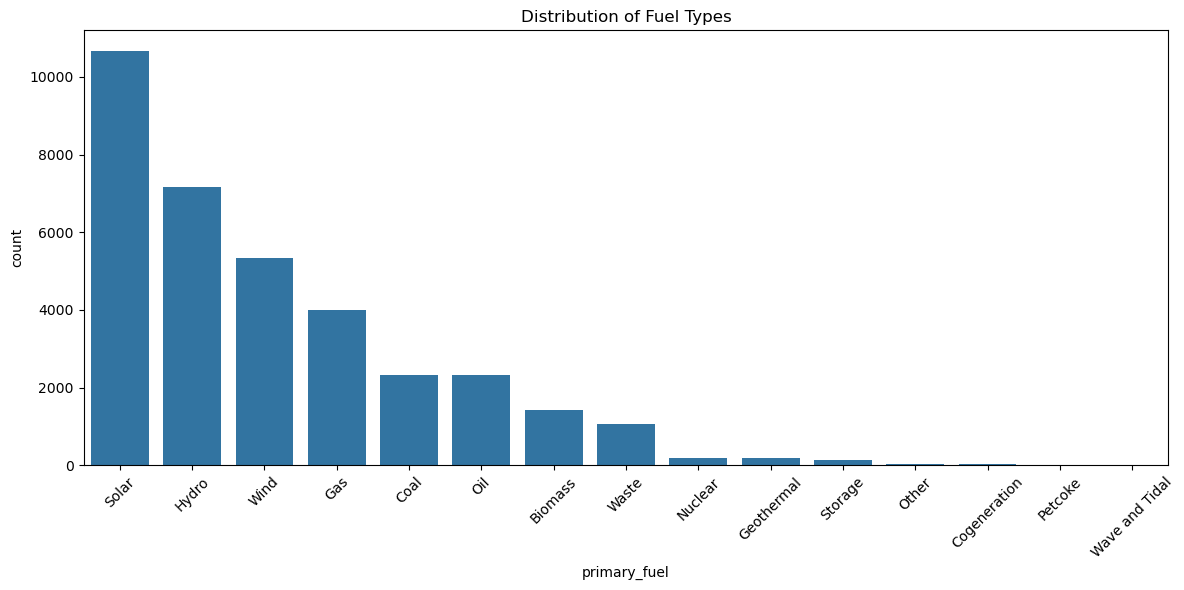


AVERAGE CAPACITY BY FUEL TYPE
primary_fuel
Biomass             23.972938
Coal               843.579828
Cogeneration        98.731707
Gas                373.449375
Geothermal          67.130952
Hydro              147.171551
Nuclear           2091.855179
Oil                112.878754
Other               84.020000
Petcoke            202.048125
Solar               17.657039
Storage             12.683704
Waste               13.809657
Wave and Tidal      55.220000
Wind                49.224126
Name: capacity_mw, dtype: float64

HYPOTHESIS TEST RESULTS
T-Statistic: 25.788324829336716
P-Value: 1.5774516338525771e-139
Reject H0: Significant difference exists.

PLANTS COMMISSIONED OVER TIME
commissioning_year
1896.0    1
1899.0    1
1900.0    6
1901.0    2
1902.0    4
dtype: int64


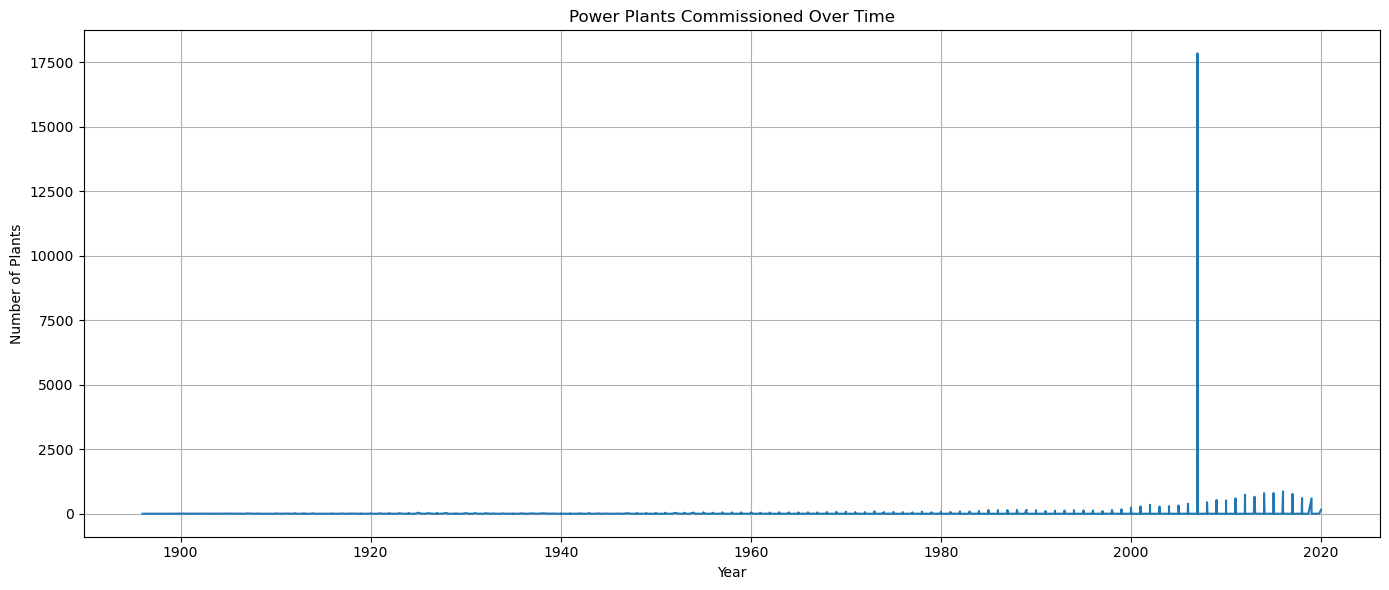


FUEL MIX EVOLUTION
primary_fuel        Biomass  Coal  Cogeneration  Gas  Geothermal  Hydro  \
commissioning_year                                                        
1896.0                    0     0             0    0           0      1   
1899.0                    0     0             0    0           0      1   
1900.0                    0     0             0    1           0      3   
1901.0                    0     0             0    0           0      2   
1902.0                    0     0             0    0           0      4   

primary_fuel        Nuclear  Oil  Other  Petcoke  Solar  Storage  Waste  \
commissioning_year                                                        
1896.0                    0    0      0        0      0        0      0   
1899.0                    0    0      0        0      0        0      0   
1900.0                    0    2      0        0      0        0      0   
1901.0                    0    0      0        0      0        0      0   
1902

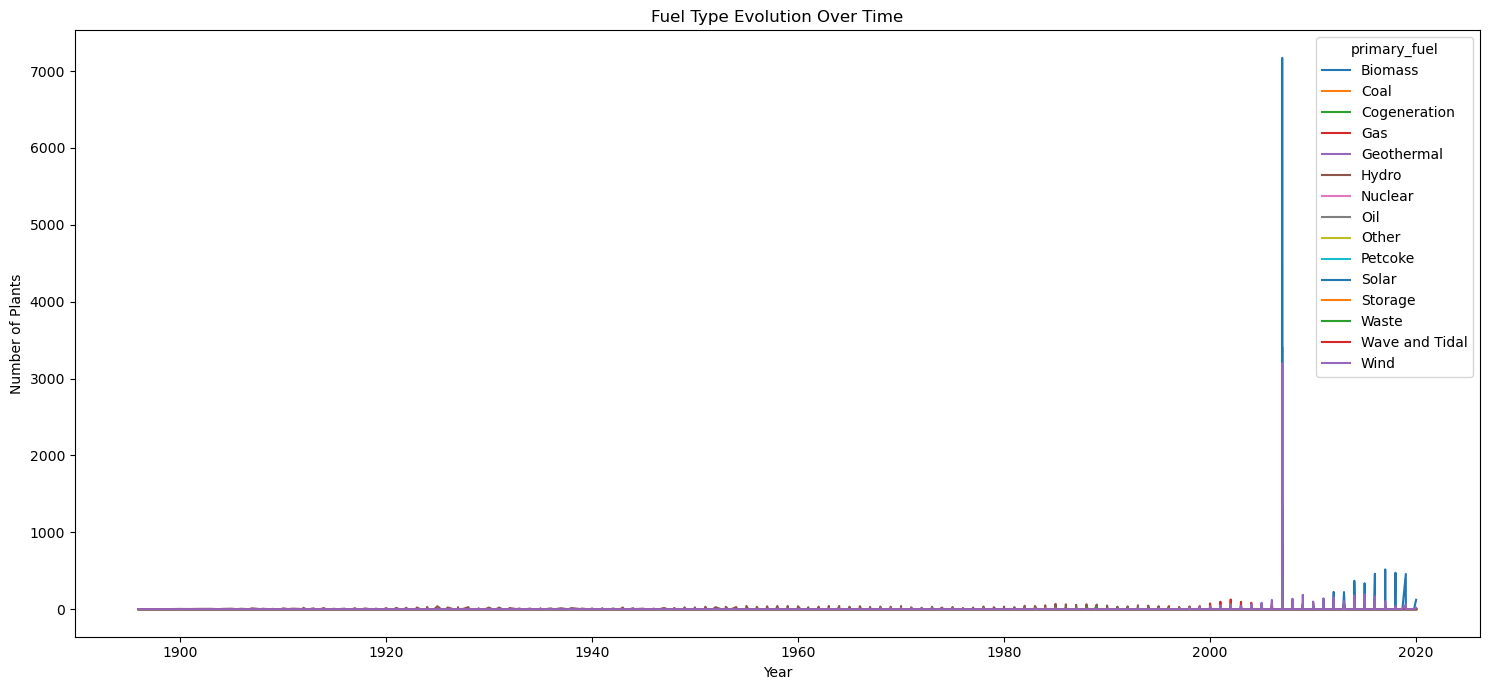

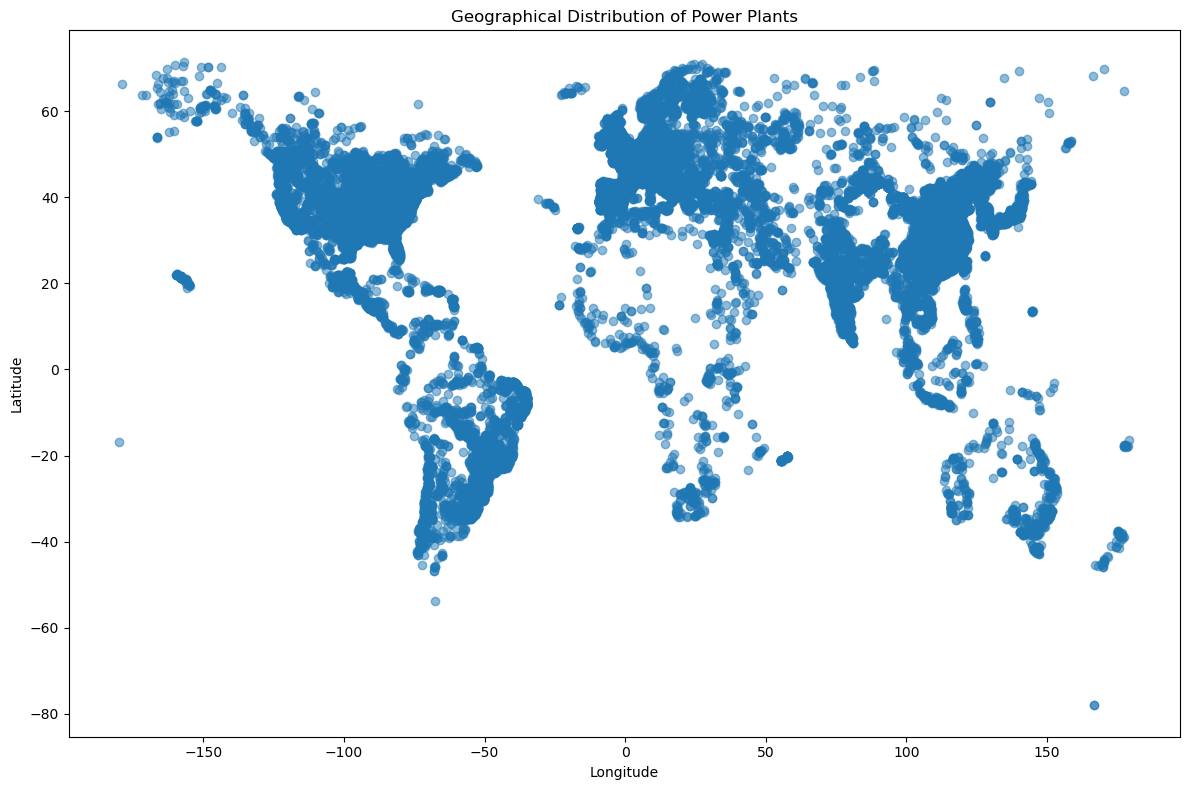


CORRELATION MATRIX
[[ 1.         -0.01321759  0.15152454]
 [-0.01321759  1.         -0.06835441]
 [ 0.15152454 -0.06835441  1.        ]]


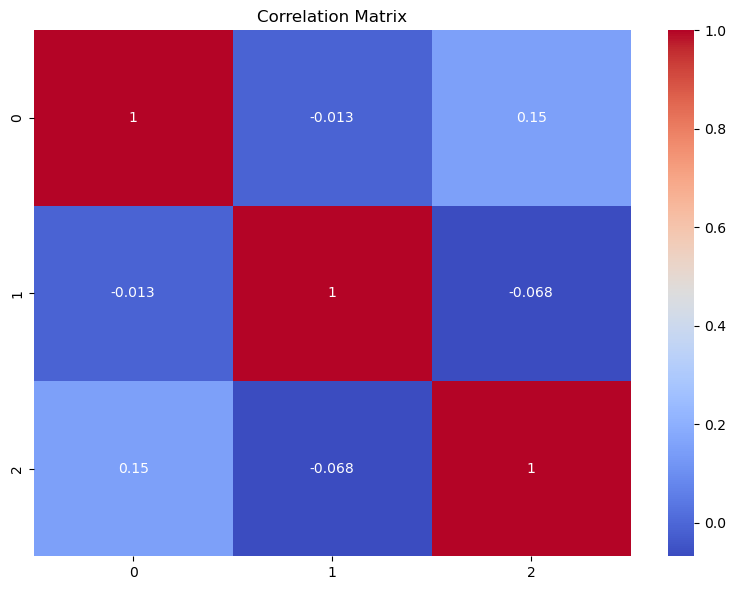


EIGENVALUES
[1.17147434 0.83840686 0.9901188 ]

EIGENVECTORS
[[-0.63986801  0.65138323  0.40776072]
 [ 0.32661662 -0.24978272  0.91155372]
 [-0.69562239 -0.7164555   0.05292462]]

LARGE POWER PLANTS
    country country_long               name   gppd_idnr  capacity_mw  \
36      DZA      Algeria     Hadjret Ennous  WRI1023768       1200.0   
49      DZA      Algeria  Koudiet Eddraouch  WRI1023769       1200.0   
68      DZA      Algeria              Terga  WRI1023770       1200.0   
95      ARG    Argentina            ALICURA  ARG0000230       1050.0   
141     ARG    Argentina          COSTANERA  ARG0000046       1982.2   

     latitude  longitude primary_fuel other_fuel1 other_fuel2  ...  \
36    36.5767     2.0797          Gas         Oil         NaN  ...   
49    36.8850     8.0778          Gas         NaN         NaN  ...   
68    35.4608    -1.2295          Gas         NaN         NaN  ...   
95   -40.5800   -70.7489        Hydro         NaN         NaN  ...   
141  -34.6260   -

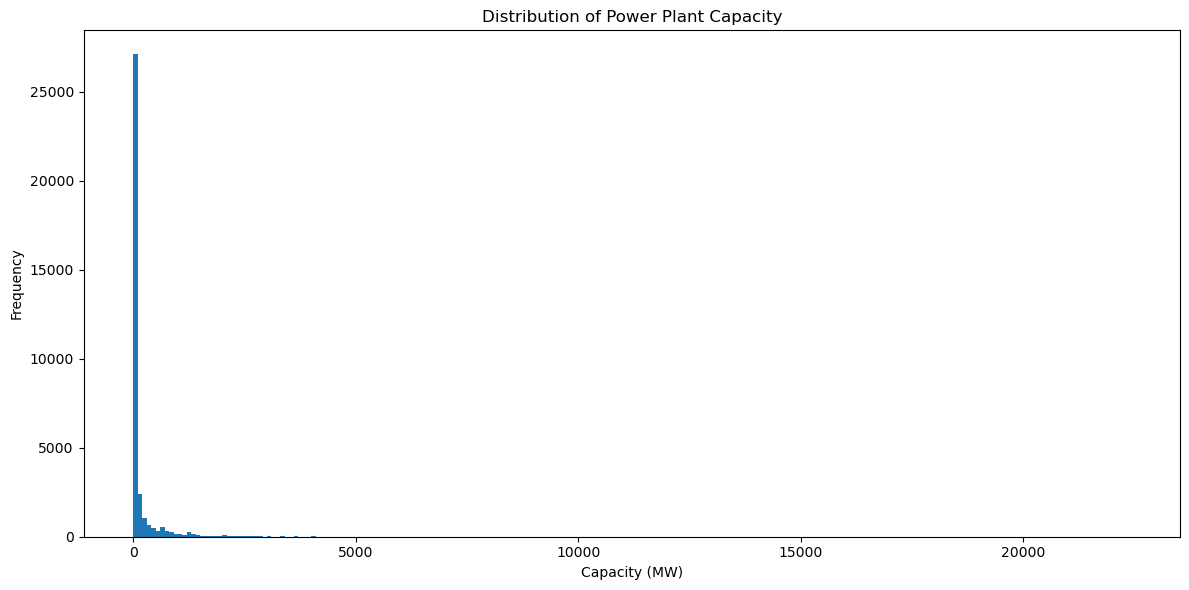


KEY INSIGHTS

1. Some countries contain significantly more power plants than others.

2. Coal and Gas remain dominant fuel sources globally.

3. Renewable energy sources are increasing over time.

4. Large-capacity plants are generally associated with fossil fuels.

5. Geographic clustering of power plants is observable.

6. Statistical testing reveals whether fuel types differ significantly in average power output.



In [ ]:

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# LOAD DATASET

# Replace with your dataset path
df = pd.read_csv("global_power_plant_database.csv")

# Display first rows
print("\nFIRST 5 ROWS")
print(df.head())

# DATASET INFORMATION

print("\nDATASET INFO")
print(df.info())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

# CHECK MISSING VALUES

print("\nMISSING VALUES")
print(df.isnull().sum())

# DATA CLEANING

# Fill missing fuel types
df['primary_fuel'] = df['primary_fuel'].fillna('Unknown')

# Convert columns to numeric
df['capacity_mw'] = pd.to_numeric(
    df['capacity_mw'],
    errors='coerce'
)

df['commissioning_year'] = pd.to_numeric(
    df['commissioning_year'],
    errors='coerce'
)

# Remove rows with missing capacity
df = df.dropna(subset=['capacity_mw'])

# Fill missing commissioning year
df['commissioning_year'] = df['commissioning_year'].fillna(
    df['commissioning_year'].median()
)

# EXPLORATORY DATA ANALYSIS

print("\nSTATISTICAL SUMMARY")
print(df.describe())

# NUMPY STATISTICS

mean_capacity = np.mean(df['capacity_mw'])
median_capacity = np.median(df['capacity_mw'])
std_capacity = np.std(df['capacity_mw'])

print("\nCAPACITY STATISTICS")
print("Mean Capacity:", mean_capacity)
print("Median Capacity:", median_capacity)
print("Standard Deviation:", std_capacity)

# POWER PLANTS BY COUNTRY

country_counts = df['country_long'].value_counts().head(10)
print("\nTOP 10 COUNTRIES")
print(country_counts)

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(
    x=country_counts.index,
    y=country_counts.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Number of Power Plants")
plt.xlabel("Country")
plt.ylabel("Number of Plants")

plt.tight_layout()
plt.show()


# POWER PLANTS BY FUEL TYPE


fuel_counts = df['primary_fuel'].value_counts()

print("\nFUEL TYPE DISTRIBUTION")
print(fuel_counts)

# Visualization
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x='primary_fuel',
    order=df['primary_fuel'].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Distribution of Fuel Types")

plt.tight_layout()
plt.show()


# STATISTICAL ANALYSIS


fuel_capacity = df.groupby(
    'primary_fuel'
)['capacity_mw'].mean()

print("\nAVERAGE CAPACITY BY FUEL TYPE")
print(fuel_capacity)


# HYPOTHESIS TESTING


# Compare Coal vs Gas

coal = df[
    df['primary_fuel'] == 'Coal'
]['capacity_mw']

gas = df[
    df['primary_fuel'] == 'Gas'
]['capacity_mw']

t_stat, p_value = stats.ttest_ind(
    coal,
    gas,
    nan_policy='omit'
)

print("\nHYPOTHESIS TEST RESULTS")
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("Reject H0: Significant difference exists.")
else:
    print("Fail to reject H0.")


# TIME SERIES ANALYSIS


plants_per_year = df.groupby(
    'commissioning_year'
).size()

print("\nPLANTS COMMISSIONED OVER TIME")
print(plants_per_year.head())

# Visualization
plt.figure(figsize=(14, 6))

plt.plot(
    plants_per_year.index,
    plants_per_year.values
)

plt.title("Power Plants Commissioned Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Plants")

plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================
# FUEL MIX EVOLUTION
# ============================================

fuel_trend = df.groupby(
    ['commissioning_year', 'primary_fuel']
).size().unstack(fill_value=0)

print("\nFUEL MIX EVOLUTION")
print(fuel_trend.head())

# Visualization
fuel_trend.plot(figsize=(15, 7))

plt.title("Fuel Type Evolution Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Plants")

plt.tight_layout()
plt.show()

# ============================================
# GEOGRAPHICAL DISTRIBUTION
# ============================================

if 'latitude' in df.columns and 'longitude' in df.columns:

    plt.figure(figsize=(12, 8))

    plt.scatter(
        df['longitude'],
        df['latitude'],
        alpha=0.5
    )

    plt.title("Geographical Distribution of Power Plants")

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    plt.tight_layout()
    plt.show()

# ============================================
# MATRIX OPERATIONS
# ============================================

numeric_df = df[
    ['capacity_mw', 'latitude', 'longitude']
].dropna()

matrix = numeric_df.to_numpy()

correlation_matrix = np.corrcoef(matrix.T)

print("\nCORRELATION MATRIX")
print(correlation_matrix)

# Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

# ============================================
# EIGENVALUES AND EIGENVECTORS
# ============================================

eigenvalues, eigenvectors = np.linalg.eig(
    correlation_matrix
)

print("\nEIGENVALUES")
print(eigenvalues)

print("\nEIGENVECTORS")
print(eigenvectors)

# ============================================
# NUMPY + PANDAS INTEGRATION
# ============================================

large_plants = df[
    np.where(df['capacity_mw'] > 1000, True, False)
]

print("\nLARGE POWER PLANTS")
print(large_plants.head())

# ============================================
# NUMPY + MATPLOTLIB
# ============================================

bins = np.arange(
    0,
    df['capacity_mw'].max(),
    100
)

plt.figure(figsize=(12, 6))

plt.hist(
    df['capacity_mw'],
    bins=bins
)

plt.title("Distribution of Power Plant Capacity")
plt.xlabel("Capacity (MW)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# ============================================
# FINAL INSIGHTS
# ============================================

print("\nKEY INSIGHTS")

print("""
1. Some countries contain significantly more power plants than others.

2. Coal and Gas remain dominant fuel sources globally.

3. Renewable energy sources are increasing over time.

4. Large-capacity plants are generally associated with fossil fuels.

5. Geographic clustering of power plants is observable.

6. Statistical testing reveals whether fuel types differ significantly in average power output.
""")

# ============================================
# END OF PROJECT
# ============================================

